# Weather Analysis: Johnstown Castle, Co. Wexford

Daily weather observations from the Johnstown Castle station in the southeast of Ireland,
covering September 2008 to January 2026.

This notebook works through three questions:

1. What does a typical year of temperature look like at this station, and how does one
   chosen year compare against that long-term pattern?
2. How likely is rain on any given day?
3. Which months are wettest, and has monthly rainfall changed over the record?

The raw file is a Met Eireann daily export. It opens with around 24 lines of station
metadata before the actual table starts, and missing values are written as blank spaces
rather than empty fields, so the first job is getting it into a clean DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Patch

%matplotlib inline

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_FILE = 'Data Johnstown Castle.csv'

## 1. Loading and cleaning

The header row cannot be assumed to sit at a fixed line number, so it is found by
scanning for the first line starting with `date,`. The comma matters: the metadata block
above contains lines like `date:  -  00 to 00 utc`, and matching on `date` alone would
stop there.

In [2]:
with open(DATA_FILE, 'r') as f:
    lines = f.readlines()

header_row = None
for i, line in enumerate(lines):
    if line.strip().lower().startswith('date,'):
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find CSV header row starting with 'date,'")

print(f'Header found on line {header_row + 1}')
print(f'Metadata lines skipped: {header_row}')

Header found on line 25
Metadata lines skipped: 24


In [3]:
df = pd.read_csv(DATA_FILE, skiprows=header_row, na_values=[' ', ''])
print(f'Raw shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Raw shape: 6343 rows x 24 columns


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,ddhm,ind.5,hg,soil,pe,evap,smd_wd,smd_md,smd_pd,glorad
0,19-sep-2008,0,16.8,0,11.7,NaN,NaN,0,0.0,1019.5,...,10.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1063.0
1,20-sep-2008,0,17.0,0,10.4,NaN,NaN,0,0.0,1021.1,...,10.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1525.0
2,21-sep-2008,0,17.0,0,9.6,NaN,NaN,0,0.2,1019.4,...,0.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1340.0
3,22-sep-2008,0,16.0,0,10.6,NaN,NaN,0,0.0,1021.4,...,0.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1572.0
4,23-sep-2008,0,14.5,0,8.1,NaN,NaN,0,0.0,1021.2,...,10.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1468.0


Dates arrive as strings like `19-sep-2008`. Anything that fails to parse becomes `NaT`
and is dropped, since a row with no usable date is no use in a time series. Calendar parts
are extracted up front for the grouping steps later.

In [4]:
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%Y', errors='coerce')

before = len(df)
df = df.dropna(subset=['date'])
print(f'Rows dropped for unparseable dates: {before - len(df)}')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear

Rows dropped for unparseable dates: 0


The three columns this analysis needs are maximum temperature, minimum temperature and
rainfall. They are coerced to numeric so that any stray non-numeric entry becomes `NaN`
rather than silently poisoning the column dtype. A row is only dropped if all three are
missing.

In [5]:
for col in ['maxtp', 'mintp', 'rain']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

before = len(df)
df = df.dropna(subset=['maxtp', 'mintp', 'rain'], how='all')
print(f'Rows dropped for having no weather data at all: {before - len(df)}')

print(f'\nClean dataset: {len(df):,} days')
print(f'Range: {df["date"].min():%d %b %Y} to {df["date"].max():%d %b %Y}')
print(f'Span:  {df["year"].max() - df["year"].min()} years')

print('\nMissing values in the three core columns:')
print(df[['maxtp', 'mintp', 'rain']].isna().sum())

Rows dropped for having no weather data at all: 1

Clean dataset: 6,342 days
Range: 19 Sep 2008 to 31 Jan 2026
Span:  18 years

Missing values in the three core columns:
maxtp    0
mintp    0
rain     2
dtype: int64


## 2. Temperature climatology

A climatology is the long-term average shape of the year. It is built by grouping every
observation by calendar day (month and day, ignoring which year it came from), so all the
1 Januaries in the record collapse into one row, all the 2 Januaries into the next, and
so on.

Alongside the mean, the 25th and 75th percentiles are kept. The gap between them is the
interquartile range, and it shows how much a given date actually varies from year to year.
A mean line on its own would hide that.

In [6]:
df['month_day'] = df['date'].dt.strftime('%m-%d')

daily_stats = df.groupby('month_day').agg(
    maxtp_mean=('maxtp', 'mean'),
    maxtp_q25=('maxtp', lambda x: x.quantile(0.25)),
    maxtp_q75=('maxtp', lambda x: x.quantile(0.75)),
    maxtp_min=('maxtp', 'min'),
    mintp_mean=('mintp', 'mean'),
    mintp_q25=('mintp', lambda x: x.quantile(0.25)),
    mintp_q75=('mintp', lambda x: x.quantile(0.75)),
).reset_index()

# A dummy year lets all 366 calendar days sit on one continuous date axis.
daily_stats['dummy_date'] = pd.to_datetime(
    '2000-' + daily_stats['month_day'], format='%Y-%m-%d'
)

print(f'Calendar days covered: {len(daily_stats)}')
daily_stats.head()

Calendar days covered: 366


,month_day,maxtp_mean,maxtp_q25,maxtp_q75,maxtp_min,mintp_mean,mintp_q25,mintp_q75,dummy_date
0,01-01,8.822222,7.400,10.850,1.0,3.522222,1.650,4.425,2000-01-01
1,01-02,7.888889,4.800,10.475,3.2,3.161111,1.125,5.525,2000-01-02
2,01-03,7.555556,4.525,9.900,3.5,3.177778,0.275,4.775,2000-01-03
3,01-04,7.511111,5.850,9.350,2.2,3.050000,1.450,4.675,2000-01-04
4,01-05,7.583333,6.025,9.775,1.1,3.277778,0.350,6.650,2000-01-05


In [7]:
overall_maxtp_q = df['maxtp'].quantile([0.25, 0.5, 0.75]).round(1)
overall_mintp_q = df['mintp'].quantile([0.25, 0.5, 0.75]).round(1)

summary = pd.DataFrame({
    'Q1': [overall_maxtp_q[0.25], overall_mintp_q[0.25]],
    'Median': [overall_maxtp_q[0.5], overall_mintp_q[0.5]],
    'Q3': [overall_maxtp_q[0.75], overall_mintp_q[0.75]],
}, index=['Max temperature (C)', 'Min temperature (C)'])

print('Overall temperature quartiles across the full record')
summary

Overall temperature quartiles across the full record


,Q1,Median,Q3
Max temperature (C),10.0,13.0,16.6
Min temperature (C),4.2,7.6,10.7


Half of all days in the record sit inside the Q1 to Q3 band. The narrowness of that
band on both rows is the signature of a maritime climate: the Atlantic keeps the
extremes in check at both ends of the year.

## 3. Picking a year to compare

2020 is the target year. If it is not present in the data, the most recent full year is
used instead. Merging the year's daily rows onto the climatology puts the actual reading
and the long-term expectation for that date side by side.

In [8]:
target_year = 2020
df_year = df[df['year'] == target_year].copy()

if df_year.empty:
    target_year = df['year'].max()
    df_year = df[df['year'] == target_year].copy()
    print(f'2020 not available, using {target_year} instead.')

df_year = df_year.merge(daily_stats, on='month_day', how='left')
print(f'{target_year}: {len(df_year)} days of observations')

2020: 366 days of observations


## 4. Rainfall

Rain gauges record trace amounts on days nobody would describe as wet. A threshold of
0.1 mm separates a genuinely rainy day from drizzle too light to measure properly, which
keeps the rainy-day probability honest.

In [9]:
rain_threshold = 0.1
df['rainy'] = df['rain'] > rain_threshold

rainy_prob = df['rainy'].mean() * 100
rainy_days = int(df['rainy'].sum())

print(f'Threshold for a rainy day : > {rain_threshold} mm')
print(f'Rainy days in the record  : {rainy_days:,} of {len(df):,}')
print(f'Probability of rain       : {rainy_prob:.1f}%')
print(f'Total rainfall recorded   : {df["rain"].sum():,.0f} mm')
print(f'Wettest single day        : {df["rain"].max():.1f} mm '
      f'on {df.loc[df["rain"].idxmax(), "date"]:%d %b %Y}')

Threshold for a rainy day : > 0.1 mm
Rainy days in the record  : 3,674 of 6,342
Probability of rain       : 57.9%
Total rainfall recorded   : 19,083 mm
Wettest single day        : 68.2 mm on 06 Sep 2010


In [10]:
df['year_month'] = df['date'].dt.to_period('M')
monthly_rain = df.groupby('year_month')['rain'].sum().reset_index()
monthly_rain['date'] = monthly_rain['year_month'].dt.to_timestamp()

# Total each calendar month within each year, then average those totals across years.
monthly_avg = df.groupby(['year', 'month'])['rain'].sum().groupby('month').mean().round(1)
wettest_month = monthly_avg.idxmax()
driest_month = monthly_avg.idxmin()

print(f'Wettest month on average: '
      f'{datetime(1900, wettest_month, 1):%B} at {monthly_avg.max():.1f} mm')
print(f'Driest month on average : '
      f'{datetime(1900, driest_month, 1):%B} at {monthly_avg.min():.1f} mm')
print(f'Ratio between them      : {monthly_avg.max() / monthly_avg.min():.1f}x')

Wettest month on average: October at 137.0 mm
Driest month on average : May at 61.1 mm
Ratio between them      : 2.2x


## 5. Monthly rainfall over time

Every month in the record as a single point. This is the view that shows whether recent
years look unusual against the rest of the record, and how spiky monthly rainfall is in
general.

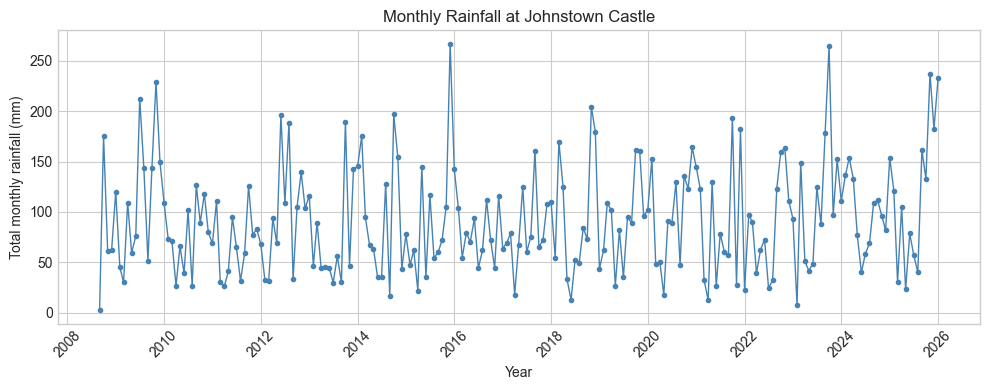

In [11]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly_rain['date'], monthly_rain['rain'],
         marker='o', linestyle='-', markersize=3, linewidth=1, color='steelblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total monthly rainfall (mm)')
ax1.set_title('Monthly Rainfall at Johnstown Castle')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_rainfall_timeseries.png', dpi=150)
plt.show()

## 6. Average rainfall by month

Collapsing the record into twelve bars shows the seasonal shape directly. Bars are shaded
against the median month, with the wettest highlighted.

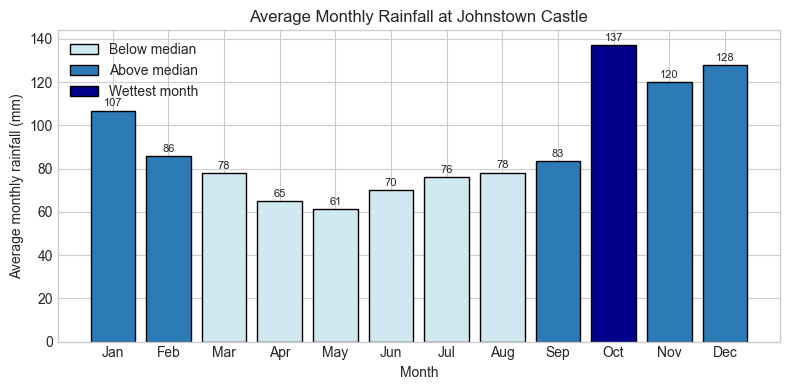

In [12]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig2, ax2 = plt.subplots(figsize=(8, 4))
colors = ['#d0e8f1' if v < monthly_avg.median() else '#2c7bb6'
          for v in monthly_avg.values]
colors[wettest_month - 1] = 'darkblue'

bars = ax2.bar(months, monthly_avg.values, color=colors, edgecolor='black')
for bar, val in zip(bars, monthly_avg.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val:.0f}', ha='center', va='bottom', fontsize=8)

legend_elements = [
    Patch(facecolor='#d0e8f1', edgecolor='black', label='Below median'),
    Patch(facecolor='#2c7bb6', edgecolor='black', label='Above median'),
    Patch(facecolor='darkblue', edgecolor='black', label='Wettest month'),
]
ax2.legend(handles=legend_elements, loc='upper left')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average monthly rainfall (mm)')
ax2.set_title('Average Monthly Rainfall at Johnstown Castle')
plt.tight_layout()
plt.savefig('avg_monthly_rainfall.png', dpi=150)
plt.show()

## 7. One year against the long-term pattern

The chart below layers four things on the same axes:

- a shaded band for the interquartile range of each calendar day, the normal spread
- the long-term mean as a dashed red line
- the coldest maximum ever recorded on each date, as a dotted floor
- the chosen year's actual daily maximum in black

Where the black line leaves the shaded band, that day was unusual for the time of year.

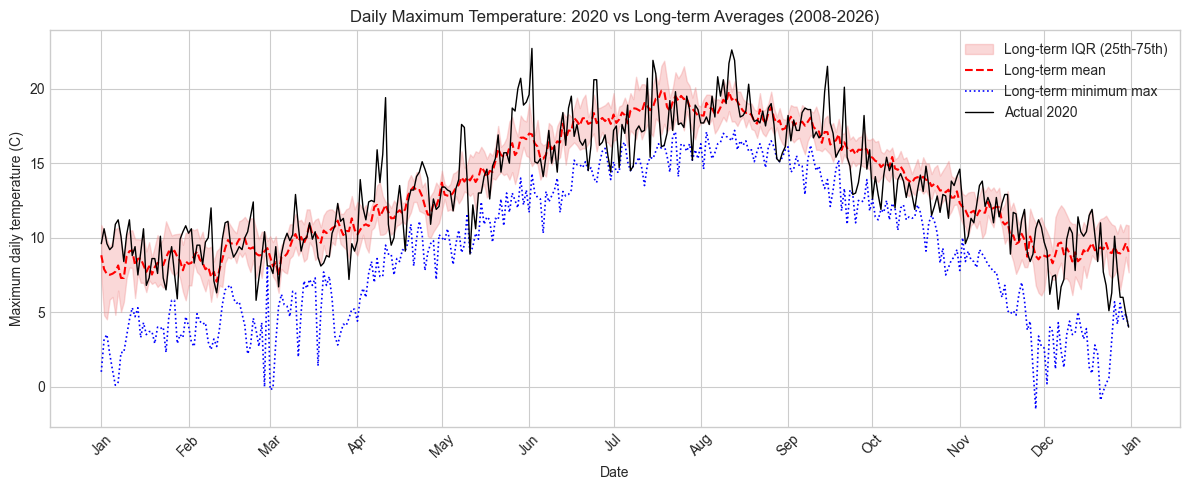

In [13]:
fig3, ax3 = plt.subplots(figsize=(12, 5))

ax3.fill_between(daily_stats['dummy_date'],
                 daily_stats['maxtp_q25'], daily_stats['maxtp_q75'],
                 color='lightcoral', alpha=0.3,
                 label='Long-term IQR (25th-75th)')
ax3.plot(daily_stats['dummy_date'], daily_stats['maxtp_mean'],
         color='red', linestyle='--', linewidth=1.5, label='Long-term mean')
ax3.plot(daily_stats['dummy_date'], daily_stats['maxtp_min'],
         color='blue', linestyle=':', linewidth=1.2, label='Long-term minimum max')
ax3.plot(df_year['dummy_date'], df_year['maxtp'],
         color='black', linewidth=1, label=f'Actual {target_year}')

ax3.set_xlabel('Date')
ax3.set_ylabel('Maximum daily temperature (C)')
ax3.set_title(f'Daily Maximum Temperature: {target_year} vs Long-term Averages '
              f'({df["year"].min()}-{df["year"].max()})')
ax3.legend(loc='upper right')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('temperature_comparison.png', dpi=150)
plt.show()

## 8. How unusual was the chosen year?

Counting days above and below the normal band turns the visual impression into a number.

In [14]:
above = (df_year['maxtp'] > df_year['maxtp_q75']).sum()
below = (df_year['maxtp'] < df_year['maxtp_q25']).sum()
within = len(df_year) - above - below

print(f'Days in {target_year} compared against the long-term IQR for each date')
print(f'  Warmer than normal : {above:>3} days  ({above / len(df_year) * 100:.1f}%)')
print(f'  Within normal range: {within:>3} days  ({within / len(df_year) * 100:.1f}%)')
print(f'  Cooler than normal : {below:>3} days  ({below / len(df_year) * 100:.1f}%)')
print()
print(f'Mean max temperature, {target_year}    : {df_year["maxtp"].mean():.2f} C')
print(f'Mean max temperature, full record : {df["maxtp"].mean():.2f} C')
print(f'Difference                        : '
      f'{df_year["maxtp"].mean() - df["maxtp"].mean():+.2f} C')

Days in 2020 compared against the long-term IQR for each date
  Warmer than normal :  68 days  (18.6%)
  Within normal range: 219 days  (59.8%)
  Cooler than normal :  79 days  (21.6%)

Mean max temperature, 2020    : 13.23 C
Mean max temperature, full record : 13.18 C
Difference                        : +0.05 C
